### Loading the dataset

In [4]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train),(x_test,y_test) = fashion_mnist.load_data()

4422102/4422102 [==============================] - 3s 1us/step


In [5]:
classes = ['t-shirt','trouser','pullover','dress','coat','sandal','shirt','snekar','bag','ankle_boot']

In [7]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

def imshow(title, image= None, size=6):
    if image.any():
        w, h = image.shape[0], image.shape[1]
        aspect_ration = w/h
        plt.figure(figsize=(size*aspect_ration,size))
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.show()
    else:
        print("image not found")

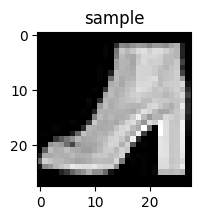

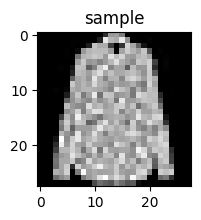

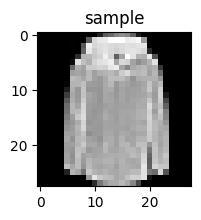

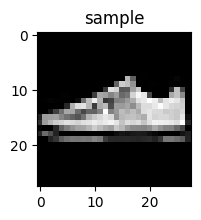

In [8]:
for i in range(0,4):
    random_num = np.random.randint(0,len(x_train))
    img = x_train[random_num]
    imshow("sample",img,size=2)

### 4. Preprocessing our dataset
1. Reshaping the data by adding 4th dimension
2. changing our datatype from uint8 to float32
3. Normalizing our data to values between 0 and 1
4. one hot encoding

In [9]:
img_rows = x_train[0].shape[0]
img_cols = x_train[0].shape[1]

# adding extra dimension
x_train = x_train.reshape(x_train.shape[0],img_rows,img_cols,1)
x_test = x_test.reshape(x_test.shape[0],img_rows,img_cols,1)

# shape for single input image
input_shape = (img_rows, img_cols, 1)

#changing from uint8 to float32
x_train =x_train.astype("float32")
x_test = x_test.astype("float32")

#Normalize the values
x_train = x_train/255.0
x_test = x_test/255.0

print("traing shape {}".format(x_train.shape))

traing shape (60000, 28, 28, 1)


In [10]:
## one hot encoding

from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

num_classes = y_test.shape[1]
print(num_classes)

10


### 5. Building the model



In [13]:
### 5. Building the model


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPool2D
from tensorflow.keras import backend as k
from tensorflow.keras.optimizers import SGD

In [15]:
model = Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=input_shape))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(num_classes,activation='softmax'))

In [16]:
model.compile(loss='categorical_crossentropy',optimizer=SGD(0.001),metrics=['accuracy'])

In [17]:
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 max_pooling2d (MaxPooling2  (None, 12, 12, 64)        0         
 D)                                                              
                                                                 
 flatten (Flatten)           (None, 9216)              0         
                                                                 
 dense (Dense)               (None, 128)               1179776   
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                        

In [18]:
batch_size = 128
epoch = 2

history = model.fit(x_train,y_train,batch_size,epoch,verbose=1,validation_data=(x_test,y_test))

Epoch 1/2
469/469 [==============================] - 125s 260ms/step - loss: 2.0734 - accuracy: 0.4026 - val_loss: 1.6583 - val_accuracy: 0.5660
Epoch 2/2
469/469 [==============================] - 116s 248ms/step - loss: 1.1851 - accuracy: 0.6355 - val_loss: 0.9298 - val_accuracy: 0.6726


In [ ]:
score = model.evaluate(x_test, y_test, verbose=0)
print('test loss', score[0])
print('test accuracy',score[1])

In [ ]:
history.history

## Regurisation techinques

1. L2 regularisaton
2. data augmentation
3. dropout
4. batchNorm

In [19]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train),(x_test,y_test) = fashion_mnist.load_data()

In [20]:
classes = ['t-shirt','trouser','pullover','dress','coat','sandal','shirt','snekar','bag','ankle_boot']

In [21]:
img_rows = x_train[0].shape[0]
img_cols = x_train[0].shape[1]

# adding extra dimension
x_train = x_train.reshape(x_train.shape[0],img_rows,img_cols,1)
x_test = x_test.reshape(x_test.shape[0],img_rows,img_cols,1)

# shape for single input image
input_shape = (img_rows, img_cols, 1)

#changing from uint8 to float32
x_train =x_train.astype("float32")
x_test = x_test.astype("float32")

#Normalize the values
x_train = x_train/255.0
x_test = x_test/255.0

print("traing shape {}".format(x_train.shape))

traing shape (60000, 28, 28, 1)


In [22]:
## one hot encoding

from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

num_classes = y_test.shape[1]
print(num_classes)

10


## regulsation
1) batch normalisation
2) dropout
3) batch normalisation

In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dropout, Flatten
from tensorflow.keras.layers import BatchNormalization, Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras import regularizers

L2 = 0.001

model = Sequential()
model.add(Conv2D(32,
                 kernel_size=(3,3),
                 activation='relu',
                 kernel_regularizer=regularizers.l2(L2),
                 input_shape = input_shape
                 ))
model.add(BatchNormalization())
model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu',
    kernel_regularizer=regularizers.l2(L2)
)

)
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.2))
model.add(Flatten())
model.add(Dense(128,activation='relu',kernel_regularizer=regularizers.l2(L2)))
model.add(Dropout(0.2))
model.add(Dense(num_classes,activation='softmax'))

In [24]:
model.compile(loss='categorical_crossentropy',
              optimizer = SGD(0.001,momentum=0.9),
              metrics = ['accuracy'])

In [25]:
print(model.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 batch_normalization (Batch  (None, 26, 26, 32)        128       
 Normalization)                                                  
                                                                 
 conv2d_3 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 batch_normalization_1 (Bat  (None, 24, 24, 64)        256       
 chNormalization)                                                
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 12, 12, 64)        0         
 g2D)                                                            
                                                      

In [26]:
batch_size = 128
epoch = 2

history = model.fit(x_train,
                    y_train,batch_size,
                    epoch,
                    verbose=1,
                    validation_data=(x_test,y_test))

Epoch 1/2
469/469 [==============================] - 159s 328ms/step - loss: 0.8263 - accuracy: 0.8127 - val_loss: 0.7998 - val_accuracy: 0.8157
Epoch 2/2
469/469 [==============================] - 147s 313ms/step - loss: 0.6502 - accuracy: 0.8701 - val_loss: 0.6081 - val_accuracy: 0.8835


## Image augmentation

In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1/.255,rotation_range=10)

In [28]:
train_datagen.flow(x_train,y_train, batch_size = batch_size)